In [27]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

df = pd.read_csv("dataset_mood_smartphone.csv")
print(df.head())
print(df.info())
print(df.describe())
df['variable'].value_counts()
df.isna().sum()
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date




# mood = df[df['variable'] == 'mood'].copy()
# sns.lineplot(x=mood['time'], y=mood['value'])

# plt.title("Mood Over Time")
# plt.xlabel("Time")
# plt.ylabel("Mood")
# plt.show()




   Unnamed: 0       id                     time variable  value
0           1  AS14.01  2014-02-26 13:00:00.000     mood    6.0
1           2  AS14.01  2014-02-26 15:00:00.000     mood    6.0
2           3  AS14.01  2014-02-26 18:00:00.000     mood    6.0
3           4  AS14.01  2014-02-26 21:00:00.000     mood    7.0
4           5  AS14.01  2014-02-27 09:00:00.000     mood    6.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376912 entries, 0 to 376911
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  376912 non-null  int64  
 1   id          376912 non-null  object 
 2   time        376912 non-null  object 
 3   variable    376912 non-null  object 
 4   value       376710 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 14.4+ MB
None
         Unnamed: 0          value
count  3.769120e+05  376710.000000
mean   4.501273e+05      40.665313
std    5.411519e+05     273.726007
min 

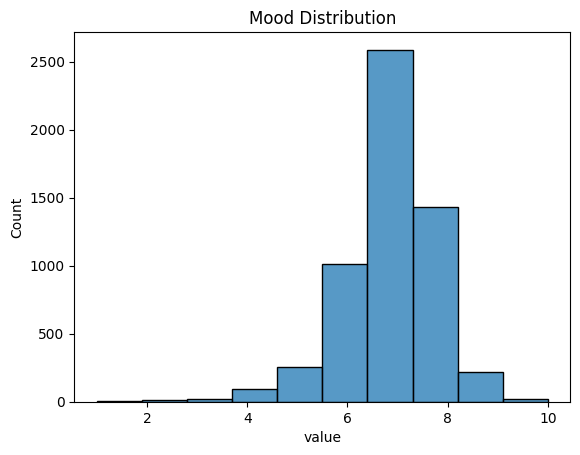

In [30]:
sns.histplot(df[df.variable=='mood']['value'], bins=10)
plt.title("Mood Distribution")
plt.show()

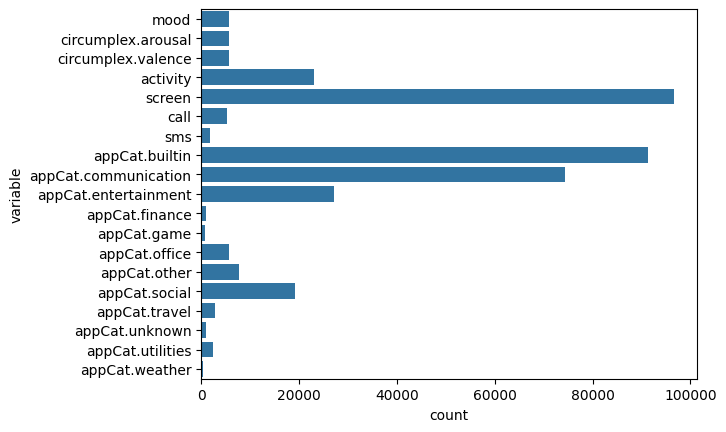

In [31]:
sns.countplot(y='variable', data=df)
plt.show()

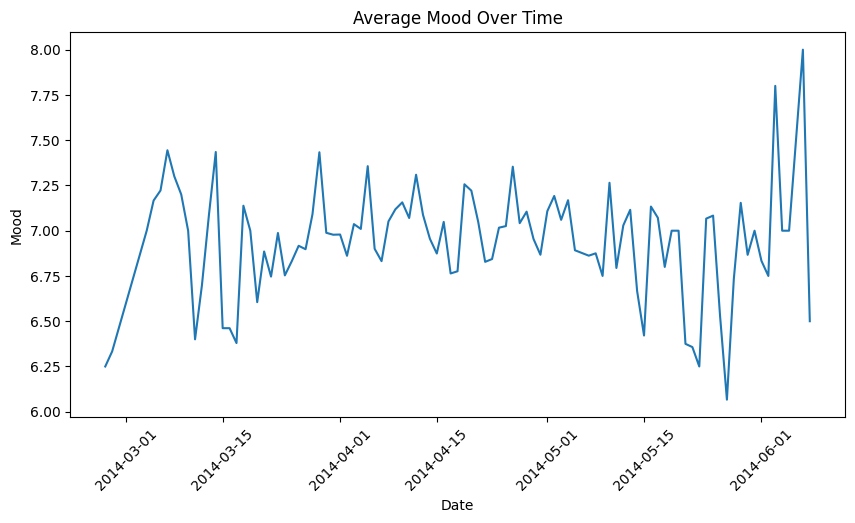

In [42]:
import numpy as np
import matplotlib.pyplot as plt

mood = df[df['variable'] == 'mood'].copy()

mood['time'] = pd.to_datetime(mood['time'])
mood['date'] = mood['time'].dt.floor('D')

daily_mood = mood.groupby('date')['value'].mean().reset_index()

x = np.asarray(daily_mood['date'])
y = np.asarray(daily_mood['value'])

plt.figure(figsize=(10,5))
plt.plot(x, y)

plt.title("Average Mood Over Time")
plt.xlabel("Date")
plt.ylabel("Mood")
plt.xticks(rotation=45)
plt.show()

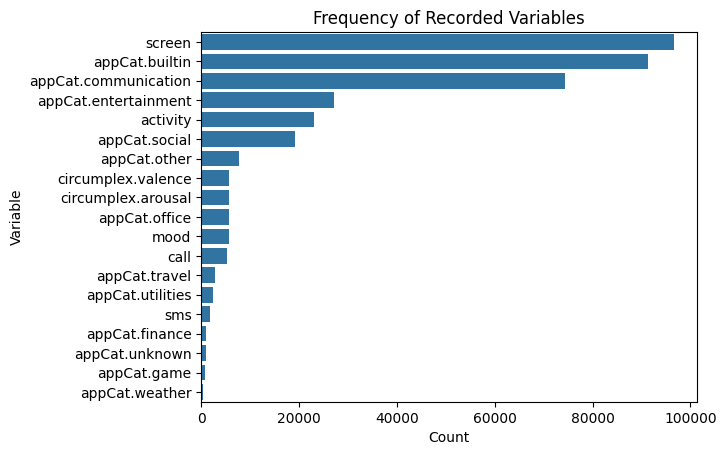

In [35]:
sns.countplot(y=df['variable'], order=df['variable'].value_counts().index)

plt.title("Frequency of Recorded Variables")
plt.xlabel("Count")
plt.ylabel("Variable")
plt.show()

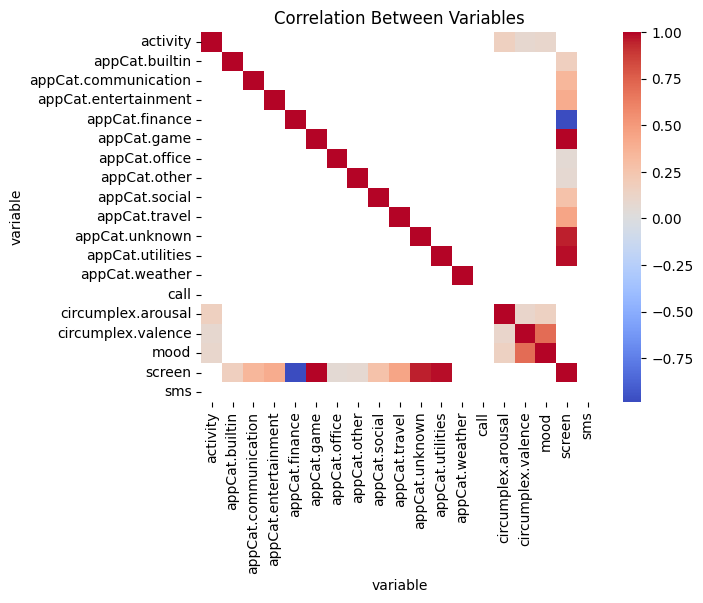

In [37]:
pivot = df.pivot_table(
    index=['id','time'],
    columns='variable',
    values='value'
)

corr = pivot.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Between Variables")
plt.show()

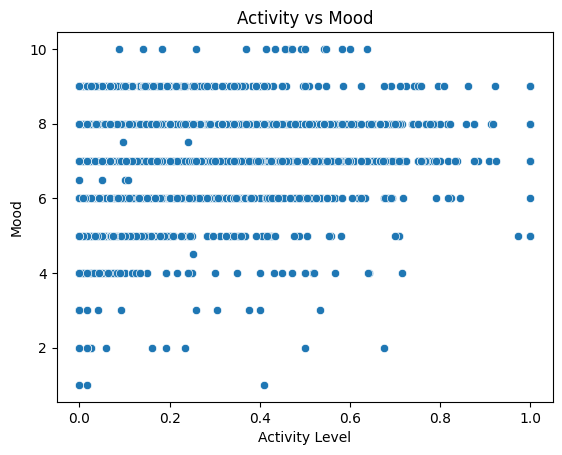

In [38]:
sns.scatterplot(x=pivot['activity'], y=pivot['mood'])

plt.title("Activity vs Mood")
plt.xlabel("Activity Level")
plt.ylabel("Mood")
plt.show()